In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from pathlib import Path
project_root = Path.cwd().resolve().parents[0]

import pandas as pd
import matplotlib.pyplot as plt

from src.curves.interpolation import CurveInterpolator
from src.curves.discount_curve import DiscountCurve

In [4]:
# synthetic yield curve data for testing
tenors = [0.25, 0.5, 1, 2, 5, 10, 20, 30]
rates = [0.03, 0.031, 0.033, 0.036, 0.039, 0.041, 0.043, 0.044]

interpolator = CurveInterpolator(
    tenors = tenors,
    rates = rates
)

daily_curve_linear = interpolator.build_interp_curve(
    max_years = 30,
    method = 'linear'
)

daily_curve_logdf = interpolator.build_interp_curve(
    max_years = 30,
    method = 'log_df'
)

display(daily_curve_linear)
display(daily_curve_logdf)


,tenor_years,zero_rate
0,0.002740,0.029011
1,0.005479,0.029022
2,0.008219,0.029033
3,0.010959,0.029044
4,0.013699,0.029055
...,...,...
10945,29.989041,0.043999
10946,29.991781,0.043999
10947,29.994521,0.043999
10948,29.997260,0.044000


,tenor_years,zero_rate
0,0.002740,0.030000
1,0.005479,0.030000
2,0.008219,0.030000
3,0.010959,0.030000
4,0.013699,0.030000
...,...,...
10945,29.989041,0.043999
10946,29.991781,0.043999
10947,29.994521,0.044000
10948,29.997260,0.044000


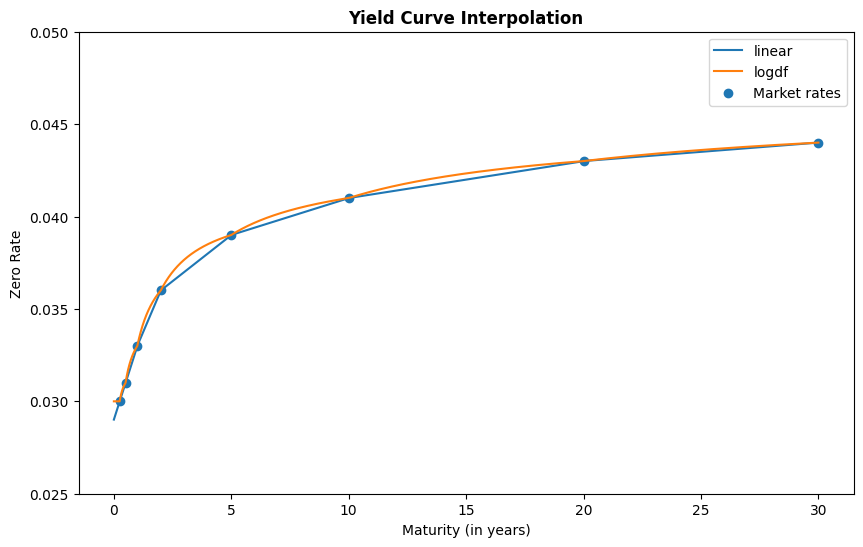

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(
    daily_curve_linear['tenor_years'],
    daily_curve_linear['zero_rate'],
    label = 'linear'
)
plt.plot(
    daily_curve_logdf['tenor_years'],
    daily_curve_logdf['zero_rate'],
    label = 'logdf'
)
plt.scatter(
    tenors,
    rates,
    label = 'Market rates',
    marker = 'o'
)

plt.title('Yield Curve Interpolation', fontweight = 'bold')
plt.xlabel('Maturity (in years)')
plt.ylabel('Zero Rate')
plt.legend()
plt.ylim(0.025, 0.05)
plt.show()

In [ ]:
# checking discount curve
discount_curve = DiscountCurve(daily_curve_logdf)
print(f'Is monotonic decreasing (Discount Factors): {discount_curve.curve['discount_factor'].is_monotonic_decreasing}')
discount_curve.curve

Is monotonic decreasing (Discount Factors): True


,tenor_years,zero_rate,discount_factor,forward_rate
0,0.002740,0.030000,0.999918,0.030
1,0.005479,0.030000,0.999836,0.030
2,0.008219,0.030000,0.999753,0.030
3,0.010959,0.030000,0.999671,0.030
4,0.013699,0.030000,0.999589,0.030
...,...,...,...,...
10945,29.989041,0.043999,0.267270,0.046
10946,29.991781,0.043999,0.267236,0.046
10947,29.994521,0.044000,0.267203,0.046
10948,29.997260,0.044000,0.267169,0.046


In [18]:
# present value check
for t in [1, 2, 5, 10, 20, 30]:
    print(f"t: {t} \tpv: {discount_curve.present_value(cashflows = [100], times = [t]):.4f}")

t: 1 	pv: 96.7539
t: 2 	pv: 93.0531
t: 5 	pv: 82.2835
t: 10 	pv: 66.3650
t: 20 	pv: 42.3162
t: 30 	pv: 26.7135
